# Help Desk Ticket SLA and Volume Forecasting

This capstone uses `data/raw/issues.csv` for two integrated workstreams: **(1) retrospective comparison of elapsed resolution time with project-configured SLA references by recorded priority; and (2) separate 7- and 30-day daily Ticket-volume forecasting experiments for capacity-planning research.** The 30-day forecast is a daily path, not one monthly total. The primary analysis includes `issue_type == Ticket` and creation dates on/after 2016-01-01 UTC, matching the period described in the accompanying source documentation.

**Important source caveat:** the CSV contains creation dates before 2016 despite the documentation's stated range. Those records are profiled but excluded from the primary scope. Dates without scoped Ticket rows are treated as zero arrivals in the forecasting series under an explicit completeness assumption that has not been independently verified. The source ends in March 2023 and cannot establish current operational performance.

The configured SLA references are project assumptions: Blocker/Highest → Critical (4h), High (8h), Medium (24h), Low/Lowest → Low (24h); `unknown` is excluded. The measured duration is calendar wall-clock time between creation and recorded resolution—not a verified business-hours SLA clock. Results are retrospective, not contractual compliance or a live warning model.

**Shared retrospective result across this notebook sequence:** among 16,735 eligible completed Tickets, 3,333 (19.9%) met the configured reference. By mapped priority: Critical 524/2,124 (24.7%); High 576/3,146 (18.3%); Medium 2,161/11,161 (19.4%); Low 72/304 (23.7%). Eligibility requires exact Ticket type, documented 2016+ scope, `Done`, known mapped priority, and valid nonnegative elapsed duration. Notebook 02 shows the detailed comparison; these same counts and caveats are the project-wide retrospective baseline.


# 03 | Seven-day and month-ahead ticket-volume forecasts

The retrospective SLA-reference comparison is a separate descriptive workstream: 3,333/16,735 eligible Tickets (19.9%) met the configured thresholds, with rates reported by priority in Notebook 02. It is not the model target. This experiment predicts one daily ticket count for each day in the next 7 or 30 days; the 30-day output is a daily forecast path, not a single monthly total. Compare a same-weekday-last-week baseline (weekly pattern repeated across the horizon), weekly ETS, XGBoost autoregression and a training-only mutual-information/PCA Ridge model. This is numeric time-series regression: classification accuracy, precision, recall and sensitivity do not apply unless a separate classification target and threshold are justified. Each horizon is backtested separately using expanding-window origins across a full validation year and a later final-test year. Select a model for each horizon by validation MAE only; the test does not choose models.

## Running the forecasting pipeline

`run_volume_forecast()` executes the full backtest using Notebook 01's daily ticket counts, fits the four candidate models (seasonal naive, weekly ETS, XGBoost autoregression, and MI/PCA Ridge) on expanding-window origins across the validation year and the later final-test year, and writes rolling metrics, predictions and selection files to `output/issue_helpdesk/volume_forecast/`. Recursive calendar features start the day after each history ends, matching the forecast target dates. The metadata records `forecast_calendar_policy: day_after_history_end_v1` so pre-correction artifacts cannot pass the current contract test.


## Model-family scope

The target is a numeric daily ticket count, so **classification algorithms** (logistic regression, decision trees, random forest, SVM) are not applicable without a separate classification target and threshold; XGBoost is used here in its regression form, not as a classifier. **Unsupervised clustering** (K-Means, DBSCAN, hierarchical clustering with elbow/silhouette diagnostics) is intentionally not applied: there is no unsupervised segmentation objective or validated cluster use case in this project (see Notebook 02). **Recommendation approaches** (collaborative or content-based) do not apply: there is no user/item interaction data or recommendation use case here. **Deep learning sequence models** (RNN, CNN, LSTM, Transformer) are intentionally not used: the daily series has 2,628 observations, short relative to typical deep sequence-model data needs, and the simpler, more transparent candidates compared here (seasonal naive, ETS, XGBoost autoregression, MI/PCA Ridge) already span classical statistical, tree-based and linear-regularized approaches appropriate for this scale and forecasting horizon.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display
from src.issues_capstone import run_volume_forecast
metadata = run_volume_forecast()
print(metadata)


{'project_name': 'Help Desk Ticket SLA and Volume Forecasting', 'forecast_calendar_policy': 'day_after_history_end_v1', 'source': 'data\\raw\\issues.csv', 'source_sha256': 'eab3b8857bc19bd917e0767fb9c30b7714d5468b25c5a1c1cd71a760e9602f02', 'source_rows': 66691, 'scoped_ticket_rows': 27348, 'scope': 'issue_type exactly Ticket; issue_created on/after 2016-01-01 UTC', 'date_start': '2016-01-03', 'date_end': '2023-03-14', 'observed_calendar_days': 2628, 'zero_ticket_days': 344, 'zero_ticket_day_pct': 13.08980213089802, 'coverage_assumption': 'The CSV is treated as a complete issue-record extract for the documented analysis period; dates without a Ticket row are zero-arrival dates. Completeness is not independently verified.', 'complete_daily_coverage_independently_verified': False, 'forecast_horizon_days': 30, 'evaluation_horizons_days': [7, 30], 'validation_calendar_days': 365, 'test_calendar_days': 365, 'rolling_origin_stride_days': 7, 'validation_forecast_origins_by_horizon': {'7': 52, 

## Building the main comparison table and lead-time chart

This cell loads the rolling backtest metrics and the validation-based model-selection record written by `run_volume_forecast()`, then reshapes the 30-day final-test predictions into weekly lead-time bands (Days 1-7 through 22-30) to see whether forecast error grows the further out the horizon reaches. The resulting `lead_errors` table and the accompanying chart are what the interpretation below ("Reading the horizon comparison") walks through.


,split,model,forecast_window_days,forecast_days,forecast_origins,MAE,RMSE,WAPE,sMAPE,signed_bias_actual_minus_forecast,validation_abs_error_p90,coverage_90_interval,interpretation
0,validation,Seasonal naive (same weekday last week),7,364,52,5.142857,7.473396,0.387497,0.572676,0.093407,12.000000,NaN,historical backtest; transfer to current opera...
1,validation,ETS (weekly additive),7,364,52,4.227266,5.790660,0.318511,0.547498,0.333868,8.801554,NaN,historical backtest; transfer to current opera...
2,validation,XGBoost autoregression (28-day lags),7,364,52,4.181157,6.020386,0.315036,0.541501,1.309540,9.359890,NaN,historical backtest; transfer to current opera...
3,validation,Ridge (MI-selected features + PCA),7,364,52,4.323507,6.293326,0.325762,0.548747,1.873757,9.491935,NaN,historical backtest; transfer to current opera...
4,test,Seasonal naive (same weekday last week),7,357,51,6.408964,9.830781,0.386030,0.528606,0.044818,12.000000,0.862745,historical backtest; transfer to current opera...
5,test,ETS (weekly additive),7,357,51,4.758324,7.398095,0.286607,0.447647,0.385932,8.801554,0.873950,historical backtest; transfer to current opera...
6,test,XGBoost autoregression (28-day lags),7,357,51,5.049222,7.722058,0.304129,0.490345,1.424021,9.359890,0.865546,historical backtest; transfer to current opera...
7,test,Ridge (MI-selected features + PCA),7,357,51,5.217716,8.006777,0.314278,0.457855,1.604747,9.491935,0.837535,historical backtest; transfer to current opera...
8,validation,Seasonal naive (same weekday last week),30,359,48,5.411806,7.803089,0.395704,0.607528,0.415972,13.000000,NaN,historical backtest; transfer to current opera...
9,validation,ETS (weekly additive),30,359,48,4.393815,6.088672,0.321270,0.534821,0.777126,9.125416,NaN,historical backtest; transfer to current opera...


selection_rule                minimum validation MAE only; test not used for...
forecast_calendar_policy                               day_after_history_end_v1
primary_horizon_days                                                         30
selected_model                                            ETS (weekly additive)
selected_models_by_horizon    {'7': {'selected_model': 'XGBoost autoregressi...
validation_mae                                                         4.393815
dtype: object

,split,model,lead_band,scored_daily_forecasts,MAE
0,test,ETS (weekly additive),Days 1-7,336,4.602410
1,test,ETS (weekly additive),Days 8-14,336,4.487370
2,test,ETS (weekly additive),Days 15-21,336,4.665047
3,test,ETS (weekly additive),Days 22-30,432,4.876151
4,test,Ridge (MI-selected features + PCA),Days 1-7,336,5.057174
5,test,Ridge (MI-selected features + PCA),Days 8-14,336,5.174846
6,test,Ridge (MI-selected features + PCA),Days 15-21,336,5.637073
7,test,Ridge (MI-selected features + PCA),Days 22-30,432,5.838199
8,test,Seasonal naive (same weekday last week),Days 1-7,336,6.041667
9,test,Seasonal naive (same weekday last week),Days 8-14,336,6.333333


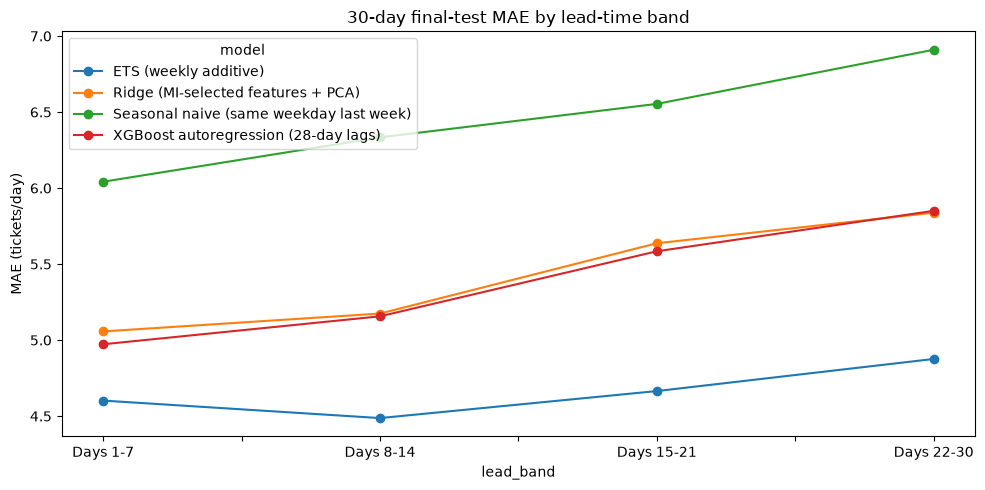

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from src.issues_capstone import REPORTS
metrics = pd.read_csv(REPORTS / "volume_forecast_rolling_metrics.csv")
selection = pd.read_json(REPORTS / "volume_forecast_model_selection.json", typ="series")
display(metrics)
display(selection)
predictions = pd.read_csv(REPORTS / "volume_forecast_rolling_predictions.csv")
predictions["absolute_error"] = (predictions["actual_tickets"] - predictions["forecast_tickets"]).abs()
predictions["lead_band"] = pd.cut(
    predictions["horizon_days"],
    bins=[0, 7, 14, 21, 30],
    labels=["Days 1-7", "Days 8-14", "Days 15-21", "Days 22-30"],
)
lead_errors = predictions.loc[predictions["forecast_window_days"].eq(30)].groupby(
    ["split", "model", "lead_band"], observed=True
).agg(
    scored_daily_forecasts=("absolute_error", "size"),
    MAE=("absolute_error", "mean"),
).reset_index()
display(lead_errors)
lead_errors.loc[lead_errors["split"].eq("test")].pivot(
    index="lead_band", columns="model", values="MAE"
).plot(
    marker="o", figsize=(10, 5), title="30-day final-test MAE by lead-time band"
)
plt.ylabel("MAE (tickets/day)")
plt.tight_layout()
plt.show()


## Reading the horizon comparison

Each row in the main comparison evaluates the complete forecast path for one horizon; the 30-day metrics score daily forecasts across all 30 lead days and overlapping historical origins. The lead-band table and chart reveal whether errors tend to rise later in the month. The seasonal-naive model repeats the latest observed seven-day pattern as its baseline for days 8–30; ETS and ML forecasts are recursively evaluated for all lead days. MAE is the average daily miss in tickets; RMSE penalizes large misses more; WAPE and sMAPE summarize relative error. The validation-calibrated 90% interval coverage is historical and does not guarantee future calibration. Because the data ends in March 2023, even a measured 30-day historical backtest does not validate next-month operations today.

## Persisted final model artifact

The validation-selected model for the primary 30-day horizon is refit on the full available history and saved as a single reproducible artifact under `models/`, alongside a metadata file recording which model was selected, its validation MAE, training data range, and usage/limitation notes. This mirrors a standard capstone deliverable (a saved model + run metadata) so the project has one canonical scoring artifact instead of only in-notebook backtest results.

In [3]:
import json
import joblib
import pandas as pd
from IPython.display import display
from src.issues_capstone import MODELS_DIR, REPORTS

model_metadata = json.loads((MODELS_DIR / "final_volume_forecast_model_metadata.json").read_text(encoding="utf-8"))
display(model_metadata)

artifact = joblib.load(MODELS_DIR / "final_volume_forecast_model.joblib")
daily = pd.read_csv(REPORTS / "daily_ticket_counts.csv", parse_dates=["date_created"])
history = pd.Series(
    daily["tickets"].to_numpy(dtype=float),
    index=pd.DatetimeIndex(pd.to_datetime(daily["date_created"], utc=True)),
)
forecast = artifact.predict(history, model_metadata["primary_horizon_days"])
print(f"Persisted model: {artifact.model_name}")
print(f"Next {model_metadata['''primary_horizon_days''']}-day forecast (first 7 days): {forecast[:7].round(2)}")


{'project_name': 'Help Desk Ticket SLA and Volume Forecasting',
 'model_name': 'ETS (weekly additive)',
 'selection_rule': 'minimum validation MAE only; test not used for selection',
 'forecast_calendar_policy': 'day_after_history_end_v1',
 'primary_horizon_days': 30,
 'validation_mae': 4.393814913939992,
 'trained_on_rows': 2628,
 'trained_on_date_start': '2016-01-03',
 'trained_on_date_end': '2023-03-14',
 'feature_columns': None,
 'artifact_path': 'models\\final_volume_forecast_model.joblib',
 'usage': 'joblib.load(this artifact).predict(history_series, horizon_days) where history_series is a daily-indexed pandas Series of ticket counts ending immediately before the forecast start date.',
 'limitations': ['Refit on the full historical series ending March 2023; not validated against current arrivals.',
  'Selected by minimum validation MAE for the primary horizon only; other horizons may prefer a different model.',
  'Same zero-arrival-day completeness assumption and non-verified SLA

Persisted model: ETS (weekly additive)
Next 30-day forecast (first 7 days): [24.33 24.98  5.37  5.18 28.48 27.01 24.73]


The forecast above is produced entirely from the persisted artifact (no retraining), demonstrating that the saved model can be loaded independently of this notebook's session — a prerequisite for any future deployment, MLflow-logged serving step, or downstream report/app that needs a stable, reusable model file. As with every other result in this project, this remains a historical-backtest artifact: it was fit on data ending March 2023 and has not been validated against current arrivals.

### In summary

Four methods are evaluated separately for one-week and one-month daily forecast paths. The corrected backtest selects XGBoost for 7 days (validation MAE 4.18; test MAE 5.05) and weekly ETS for 30 days (validation MAE 4.39; test MAE 4.67). ETS has a lower 7-day test MAE of 4.76, but the selection remains XGBoost because the final test must not choose the winner. Only the primary 30-day ETS model is refitted on full history and saved as the reusable artifact. All scores remain historical, not evidence of current operations.